# Train EfficientNet - Phân loại côn trùng

Notebook huấn luyện **EfficientNet** (viết từ đầu, không dùng pretrained) trên tập dữ liệu côn trùng 13 lớp.

| Variant | Params | Block config | Growth rate |
|---|---|---|---|
| EfficientNet-B3 | 12M | [6, 12, 24, 16] | 32 |
| EfficientNet-169 | ~12.5M | [6, 12, 32, 32] | 32 |
| EfficientNet-201 | ~18.1M | [6, 12, 48, 32] | 32 |

## 1. Mount Drive & Copy dữ liệu

## 2. Khám phá dữ liệu

/var/folders/hg/dtfsyvn54rs5tr074lnfrr7w0000gn/T/ipykernel_78259/1128686343.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_counts, x="Split", y="Count", palette="viridis", ax=axes[0])
/var/folders/hg/dtfsyvn54rs5tr074lnfrr7w0000gn/T/ipykernel_78259/1128686343.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count", palette="Set2", ax=axes[1])


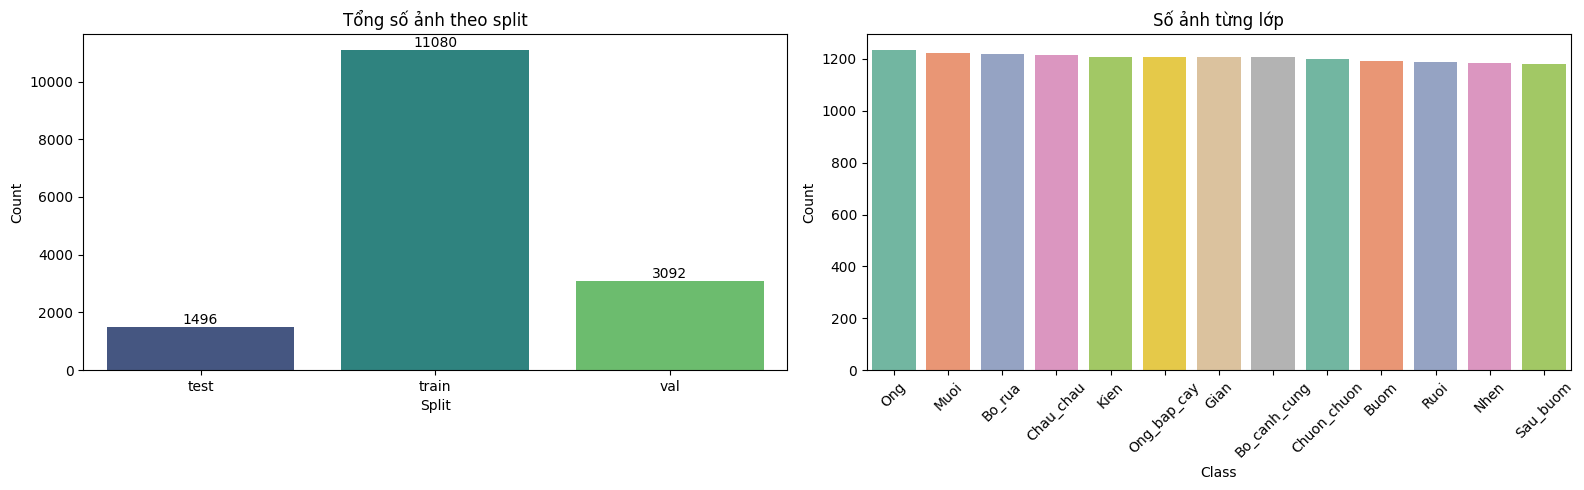

Split
test      1496
train    11080
val       3092


In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

dataset_dir = "/Users/nguyenly/Desktop/code/XLA/data/dataset"
splits = ["train", "val", "test"]
data = []

for split in splits:
    split_dir = os.path.join(dataset_dir, split)
    if not os.path.exists(split_dir):
        continue
    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            n = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
            data.append({"Split": split, "Class": class_name, "Count": n})

df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

split_counts = df.groupby("Split")["Count"].sum().reset_index()
sns.barplot(data=split_counts, x="Split", y="Count", palette="viridis", ax=axes[0])
axes[0].set_title("Tổng số ảnh theo split")
for i, row in split_counts.iterrows():
    axes[0].text(i, row.Count, str(int(row.Count)), ha="center", va="bottom")

class_counts = df.groupby("Class")["Count"].sum().reset_index().sort_values("Count", ascending=False)
sns.barplot(data=class_counts, x="Class", y="Count", palette="Set2", ax=axes[1])
axes[1].set_title("Số ảnh từng lớp")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
print(df.groupby("Split")["Count"].sum().to_string())

## 3. Setup & Import

In [2]:
import sys
import os

project_root = "/Users/nguyenly/Desktop/code/XLA"  # <-- sửa tên folder nếu cần
src_dir = os.path.join(project_root, "src")

assert os.path.exists(src_dir), f"Không tìm thấy: {src_dir}"

if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

os.chdir(project_root)
print("CWD:", os.getcwd())

import torch
import torch.nn as nn
import torch.optim as optim

from utils import config
from data.preprocess import get_dataloaders
from models.efficientnet import get_efficientnet_b3
from training.evaluate import evaluate_model
from utils.visualize import plot_training_history

print(f"Device  : {config.DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"Epochs  : {config.EPOCHS}")
print(f"LR      : {config.LEARNING_RATE}")
print(f"Batch   : {config.BATCH_SIZE}")

CWD: /Users/nguyenly/Desktop/code/XLA
Device  : mps
PyTorch : 2.11.0
Epochs  : 70
LR      : 0.001
Batch   : 32


## 4. Load dữ liệu

In [3]:
train_loader, val_loader, test_loader, classes = get_dataloaders()

print(f"Số lớp  : {len(classes)}")
print(f"Classes : {classes}")
print(f"Train   : {len(train_loader)} batches ({len(train_loader.dataset)} ảnh)")
print(f"Val     : {len(val_loader)} batches ({len(val_loader.dataset)} ảnh)")
print(f"Test    : {len(test_loader)} batches ({len(test_loader.dataset)} ảnh)")

Loading data từ: /Users/nguyenly/Desktop/code/XLA/data
Số lớp  : 13
Classes : ['Bo_canh_cung', 'Bo_rua', 'Buom', 'Chau_chau', 'Chuon_chuon', 'Gian', 'Kien', 'Muoi', 'Nhen', 'Ong', 'Ong_bap_cay', 'Ruoi', 'Sau_buom']
Train   : 346 batches (11080 ảnh)
Val     : 97 batches (3092 ảnh)
Test    : 47 batches (1496 ảnh)


## 5. Khởi tạo mô hình

Đổi `MODEL_NAME` để chọn variant:
- `'efficientnet121'` — nhẹ nhất (~7M params), train nhanh
- `'efficientnet169'` — cân bằng (~12.5M params)
- `'efficientnet201'` — nặng nhất (~18M params), kết quả tốt nhất

In [4]:
MODEL_NAME = "efficientnet_b3"

_model_map = {
    "efficientnet_b3": get_efficientnet_b3,
}

if MODEL_NAME not in _model_map:
    raise ValueError(f"MODEL_NAME phải là một trong {list(_model_map.keys())}")

num_classes = len(classes)
model = _model_map[MODEL_NAME](num_classes=num_classes)
model = model.to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model         : {MODEL_NAME.upper()}")
print(f"Device        : {config.DEVICE}")
print(f"Tổng tham số  : {total_params:,}")
print(f"Tham số train : {train_params:,}")

Model         : EFFICIENTNET_B3
Device        : mps
Tổng tham số  : 10,716,213
Tham số train : 10,716,213


## 6. Cấu hình Optimizer & Scheduler

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.EPOCHS,
    eta_min=1e-5
)

models_saved_dir = os.path.join(project_root, "models_saved")
os.makedirs(models_saved_dir, exist_ok=True)
save_path = os.path.join(models_saved_dir, f"best_{MODEL_NAME}.pth")

print(f"Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print(f"Optimizer : SGD (lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)")
print(f"Scheduler : CosineAnnealingLR (T_max={config.EPOCHS}, eta_min=1e-5)")
print(f"Save path : {save_path}")

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : SGD (lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)
Scheduler : CosineAnnealingLR (T_max=70, eta_min=1e-5)
Save path : /Users/nguyenly/Desktop/code/XLA/models_saved/best_efficientnet_b3.pth


## 7. Huấn luyện

In [6]:
import time

best_val_loss = float("inf")
early_stop_counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Bắt đầu huấn luyện [{MODEL_NAME.upper()}] trên {config.DEVICE.upper()}")
print(f"Train: {len(train_loader.dataset)} ảnh | Val: {len(val_loader.dataset)} ảnh")
print(f"Batches/epoch: {len(train_loader)}\n")

for epoch in range(1, config.EPOCHS + 1):
    print(f"Epoch {epoch}/{config.EPOCHS}")
    epoch_start = time.time()

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    n_batches = len(train_loader)

    for batch_idx, (inputs, labels) in enumerate(train_loader, 1):
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        bar_len = 30
        filled = int(bar_len * batch_idx / n_batches)
        bar = "=" * filled + ">" + "." * (bar_len - filled - 1) if filled < bar_len else "=" * bar_len
        elapsed_so_far = time.time() - epoch_start
        print(
            f"\r{batch_idx}/{n_batches} [{bar}] - "
            f"{elapsed_so_far:.0f}s - "
            f"loss: {running_loss/total:.4f} - acc: {correct/total:.4f}",
            end="", flush=True
        )

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= total
    val_acc   = correct / total
    elapsed = time.time() - epoch_start

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    bar = "=" * 30
    print(
        f"\r{n_batches}/{n_batches} [{bar}] - "
        f"{elapsed:.0f}s - "
        f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
        f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        prev = best_val_loss
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), save_path)
        tag = "inf" if prev == float("inf") else f"{prev:.4f}"
        print(f"   val_loss improved from {tag} to {val_loss:.4f}, saving → {os.path.basename(save_path)}")
    else:
        early_stop_counter += 1
        print(f"   val_loss did not improve from {best_val_loss:.4f} ({early_stop_counter}/{config.EARLY_STOPPING_PATIENCE})")
        if early_stop_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping tại epoch {epoch}!")
            break

print(f"\n=== HOÀN TẤT HUẤN LUYỆN ===")
print(f"Best val_loss : {best_val_loss:.4f}")
print(f"Model saved   : {save_path}")

Bắt đầu huấn luyện [EFFICIENTNET_B3] trên MPS
Train: 11080 ảnh | Val: 3092 ảnh
Batches/epoch: 346

Epoch 1/70
14/346 [=>............................] - 21s - loss: 2.6688 - acc: 0.1027

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


21/346 [=>............................] - 25s - loss: 2.6449 - acc: 0.1131

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


146/346 [============>.................] - 102s - loss: 2.6022 - acc: 0.1297

...

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


346/346 [==============================] - 252s - loss: 0.6899 - acc: 0.9481 - val_loss: 0.8589 - val_acc: 0.8917
   val_loss did not improve from 0.8545 (1/8)
Epoch 33/70
19/346 [=>............................] - 15s - loss: 0.6644 - acc: 0.9589

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


23/346 [=>............................] - 18s - loss: 0.6667 - acc: 0.9579

: 

## 8. Biểu đồ Loss & Accuracy

In [1]:
plot_training_history(history, MODEL_NAME, models_saved_dir)

NameError: name 'plot_training_history' is not defined

## 9. Đánh giá trên tập Test

In [ ]:
model.load_state_dict(torch.load(save_path, map_location=config.DEVICE))
model = model.to(config.DEVICE)

evaluate_model(model, test_loader, test_loader.dataset, classes, models_saved_dir)

## 10. Confusion Matrix chi tiết

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(config.DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            square=True, ax=axes[0], annot_kws={"size": 10})
axes[0].set_title(f"Confusion Matrix - {MODEL_NAME.upper()}\n(Số lượng)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dự đoán"); axes[0].set_ylabel("Thực tế")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Greens",
            xticklabels=classes, yticklabels=classes,
            square=True, ax=axes[1], annot_kws={"size": 10}, vmin=0, vmax=1)
axes[1].set_title(f"Confusion Matrix - {MODEL_NAME.upper()}\n(Tỷ lệ %)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Dự đoán"); axes[1].set_ylabel("Thực tế")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"confusion_matrix_{MODEL_NAME}.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 70)
print(f"CLASSIFICATION REPORT - {MODEL_NAME.upper()}")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

accuracy = (all_preds == all_labels).mean()
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Tổng mẫu test : {len(all_labels)}")
print(f"Đúng          : {(all_preds == all_labels).sum()}")
print(f"Sai           : {(all_preds != all_labels).sum()}")

errors = [(classes[i], classes[j], cm[i][j])
          for i in range(len(classes)) for j in range(len(classes))
          if i != j and cm[i][j] > 0]
errors.sort(key=lambda x: x[2], reverse=True)
print("\nTOP 5 CẶP NHẦM LẪN NHIỀU NHẤT:")
for actual, predicted, count in errors[:5]:
    print(f"  {actual:20s} → {predicted:20s} : {count} lần")